# Remark 1: Wrong terms

Consider the following inferred LV equations from training data (in notebook 13_1), as follows:
$$
\begin{align}
    \dot x &=1.248x+0.124x^2-0.885xy-0.066x^3 \\
    \dot y&=-1.8y + 0.787xy
\end{align}
$$
For $y_0=0$ we have the following growth equation for $\dot x$:
$$
\dot x = 1.248x+0.124x^2-0.066x^3 = x(1.248+0.124x-0.066x^2)= x(b(x)-m(x))
$$
This is WRONG, as it possibly indicates Allee effect and self-limiting wrong whenever in the original equations the populations were assumed to grow exponentially 

In this notebook we will plot $b(x), m(x)$ for the thesis

In [57]:
import numpy as np 
import matplotlib.pyplot as plt 
from scipy.optimize import fsolve
from scipy.integrate import solve_ivp


In [52]:
f = (lambda x: 1.248 + 0.124*(x**1)-0.066*(x**2))
b = (lambda x: 1.248 + 0.124*(x**1))
m = (lambda x: 0.066*(x**2))


In [53]:
xrange = np.linspace(0, 6)
b_calc = b(xrange)
m_calc = m(xrange)


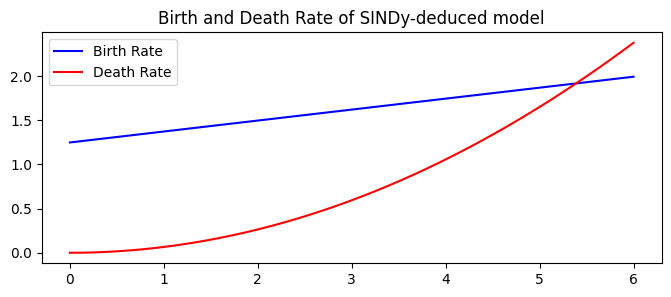

In [54]:
fig, ax = plt.subplots(figsize=(8, 3))

ax.plot(xrange, b_calc, color="blue", label="Birth Rate")
ax.plot(xrange, m_calc, color="Red", label="Death Rate")
ax.legend()
ax.set_title("Birth and Death Rate of SINDy-deduced model")

plt.show()

In [56]:
intersec = fsolve(f, 5)
intersec

array([5.38816364])

## Remark 1.5 Simulating UDE-enhanced SINDy model without optimizations

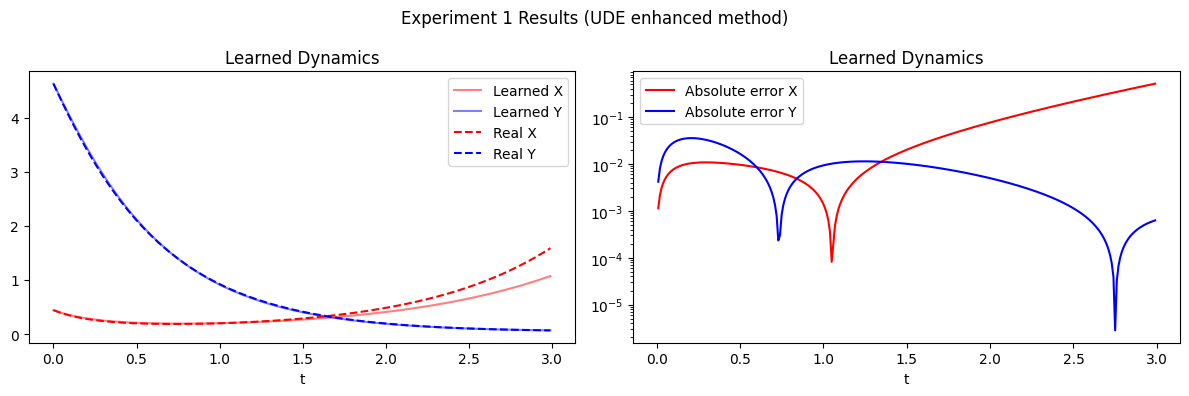

In [105]:
# new parameters
alpha = 1.064
delta = 1.949
beta = 0.791
gamma = 1.350

# real parameters
alpha_real = 1.3
delta_real = 1.8
beta_real = 0.9
gamma_real = 0.8


def lotka_volterra(t, data, a, d, b, gamma):
    x = data[0]
    y = data[1]
    return np.array([a * x - b * x * y, 
                    -d * y + gamma * x * y])

x0 = (0.44249296, 4.6280594)

sol = solve_ivp(lotka_volterra, t_span = [0, 3], t_eval=np.arange(0, 3, 0.01), args= (alpha, delta, beta, gamma), y0 = x0, rtol=1e-9, atol=1e-9)
sol_real = solve_ivp(lotka_volterra, t_span = [0, 3], t_eval=np.arange(0, 3, 0.01), args= (alpha_real, delta_real, beta_real, gamma_real), y0 = x0, rtol=1e-9, atol=1e-9)
data = sol.y
data_real = sol_real.y



T = sol.t
X = data[0]
Y = data[1]

X_real = data_real[0]
Y_real = data_real[1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plt.sca(axes[0])

plt.plot(T, X, "-", label="Learned X", color="red", alpha=0.5)
plt.plot(T, Y, "-", label="Learned Y", color="blue", alpha=0.5)
plt.plot(T, X_real, "--", label="Real X", color="red")
plt.plot(T, Y_real, "--", label="Real Y", color="blue")
plt.xlabel("t")
plt.title("Learned Dynamics")
plt.legend()

plt.sca(axes[1])
plt.semilogy(T[1:], np.abs(X[1:]-X_real[1:]), label="Absolute error X", color='red')
plt.semilogy(T[1:], np.abs(Y[1:]-Y_real[1:]), label="Absolute error Y", color='blue')
plt.xlabel("t")
plt.title("Learned Dynamics")
plt.legend()

plt.suptitle("Experiment 1 Results (UDE enhanced method)")
plt.tight_layout()

plt.show()




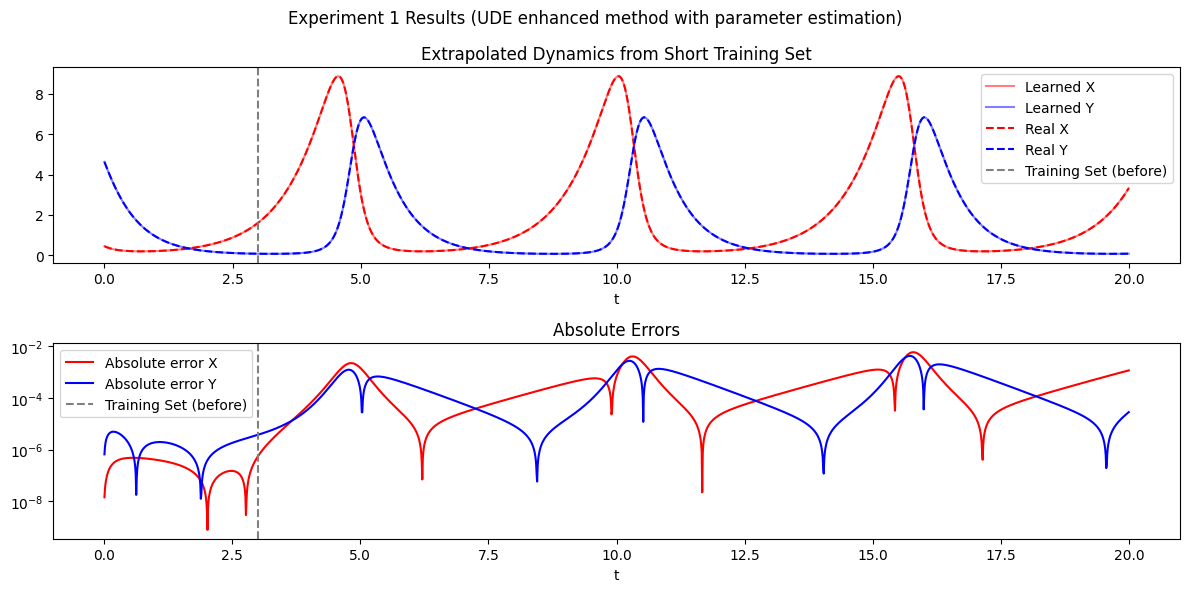

In [100]:
# plot extrapolated fit
# new parameters
alpha = 1.30000148
delta = 1.8000203
beta = 0.90000097
gamma = 0.80007929

# real parameters
alpha_real = 1.3
delta_real = 1.8
beta_real = 0.9
gamma_real = 0.8


def lotka_volterra(t, data, a, d, b, gamma):
    x = data[0]
    y = data[1]
    return np.array([a * x - b * x * y, 
                    -d * y + gamma * x * y])

x0 = (0.44249296, 4.6280594)

T_MAX = 20
sol = solve_ivp(lotka_volterra, t_span = [0, T_MAX], t_eval=np.arange(0, T_MAX, 0.01), args= (alpha, delta, beta, gamma), y0 = x0, rtol=1e-9, atol=1e-9)
sol_real = solve_ivp(lotka_volterra, t_span = [0, T_MAX], t_eval=np.arange(0, T_MAX, 0.01), args= (alpha_real, delta_real, beta_real, gamma_real), y0 = x0, rtol=1e-9, atol=1e-9)
data = sol.y
data_real = sol_real.y

T = sol.t
X = data[0]
Y = data[1]

X_real = data_real[0]
Y_real = data_real[1]

fig, axes = plt.subplots(2,1, figsize=(12, 6))

plt.sca(axes[0])

plt.plot(T, X, "-", label="Learned X", color="red", alpha=0.5)
plt.plot(T, Y, "-", label="Learned Y", color="blue", alpha=0.5)
plt.plot(T, X_real, "--", label="Real X", color="red")
plt.plot(T, Y_real, "--", label="Real Y", color="blue")
plt.xlabel("t")
plt.axvline(3, label="Training Set (before)", color="grey", linestyle="--")
plt.title("Extrapolated Dynamics from Short Training Set")
plt.legend()

plt.sca(axes[1])
plt.semilogy(T[1:], np.abs(X[1:]-X_real[1:]), label="Absolute error X", color='red')
plt.semilogy(T[1:], np.abs(Y[1:]-Y_real[1:]), label="Absolute error Y", color='blue')
plt.xlabel("t")
plt.title("Absolute Errors")
plt.axvline(3, label="Training Set (before)", color="grey", linestyle="--")
plt.legend()

plt.suptitle("Experiment 1 Results (UDE enhanced method with parameter estimation)")

plt.tight_layout()
plt.show()




## Remark 1.75: Other UDE architecture vs Rackauckas

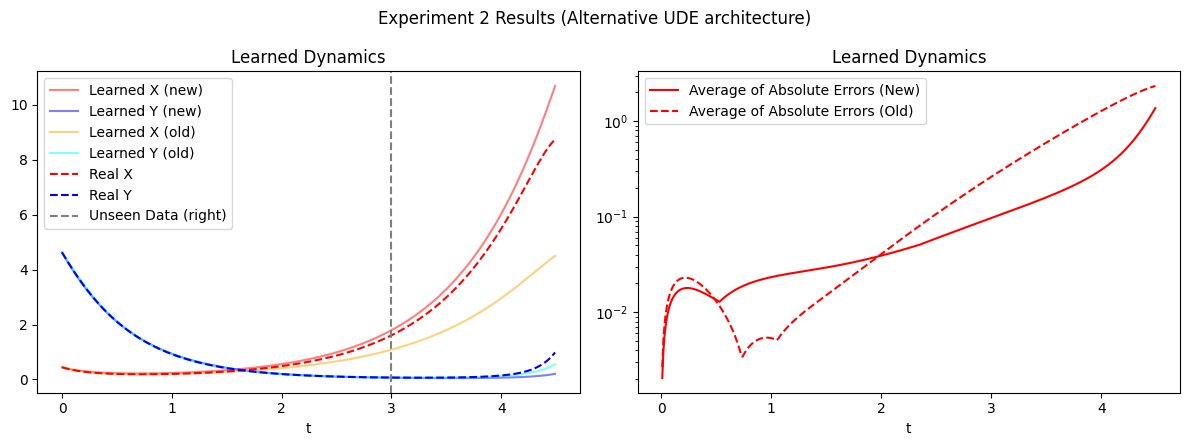

In [136]:
#(x)' =  1.256 x + -0.815 x y
# (y)' = -1.729 y +  0.506 x y
# old parameters
alpha_old = 1.064
delta_old = 1.949
beta_old = 0.791
gamma_old = 1.350

# new parameters
alpha = 1.256
delta = 1.729
beta = 0.815
gamma = 0.506

# real parameters
alpha_real = 1.3
delta_real = 1.8
beta_real = 0.9
gamma_real = 0.8


def lotka_volterra(t, data, a, d, b, gamma):
    x = data[0]
    y = data[1]
    return np.array([a * x - b * x * y, 
                    -d * y + gamma * x * y])

x0 = (0.44249296, 4.6280594)

T_MAX = 4.5

sol_old = solve_ivp(lotka_volterra, t_span = [0, T_MAX], t_eval=np.arange(0, T_MAX, 0.01), args= (alpha_old, delta_old, beta_old, gamma_old), y0 = x0, rtol=1e-9, atol=1e-9)
sol = solve_ivp(lotka_volterra, t_span = [0, T_MAX], t_eval=np.arange(0, T_MAX, 0.01), args= (alpha, delta, beta, gamma), y0 = x0, rtol=1e-9, atol=1e-9)
sol_real = solve_ivp(lotka_volterra, t_span = [0, T_MAX], t_eval=np.arange(0, T_MAX, 0.01), args= (alpha_real, delta_real, beta_real, gamma_real), y0 = x0, rtol=1e-9, atol=1e-9)
data_old = sol_old.y
data = sol.y
data_real = sol_real.y



T = sol.t
X = data[0]
Y = data[1]

X_real = data_real[0]
Y_real = data_real[1]
X_old = data_old[0]
Y_old = data_old[1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

plt.sca(axes[0])

plt.plot(T, X, "-", label="Learned X (new)", color="red", alpha=0.5)
plt.plot(T, Y, "-", label="Learned Y (new)", color="blue", alpha=0.5)
plt.plot(T, X_old, "-", label="Learned X (old)", color="orange", alpha=0.5)
plt.plot(T, Y_old, "-", label="Learned Y (old)", color="cyan", alpha=0.5)
plt.plot(T, X_real, "--", label="Real X", color="red")
plt.plot(T, Y_real, "--", label="Real Y", color="blue")
plt.axvline(3, linestyle="--", color="grey", label="Unseen Data (right)")
plt.xlabel("t")
plt.title("Learned Dynamics")
plt.legend()

plt.sca(axes[1])
plt.semilogy(T[1:], 0.5*(np.abs(X[1:]-X_real[1:])+ np.abs(Y[1:]-Y_real[1:])), label="Average of Absolute Errors (New)", color='red')
plt.semilogy(T[1:], 0.5*(np.abs(X_old[1:]-X_real[1:])+np.abs(Y_old[1:]-Y_real[1:])), label="Average of Absolute Errors (Old)", color='red', linestyle="--")
plt.xlabel("t")
plt.title("Learned Dynamics")
plt.legend()

plt.suptitle("Experiment 2 Results (Alternative UDE architecture)")
plt.tight_layout()

plt.show()




# Remark 2: other parameters

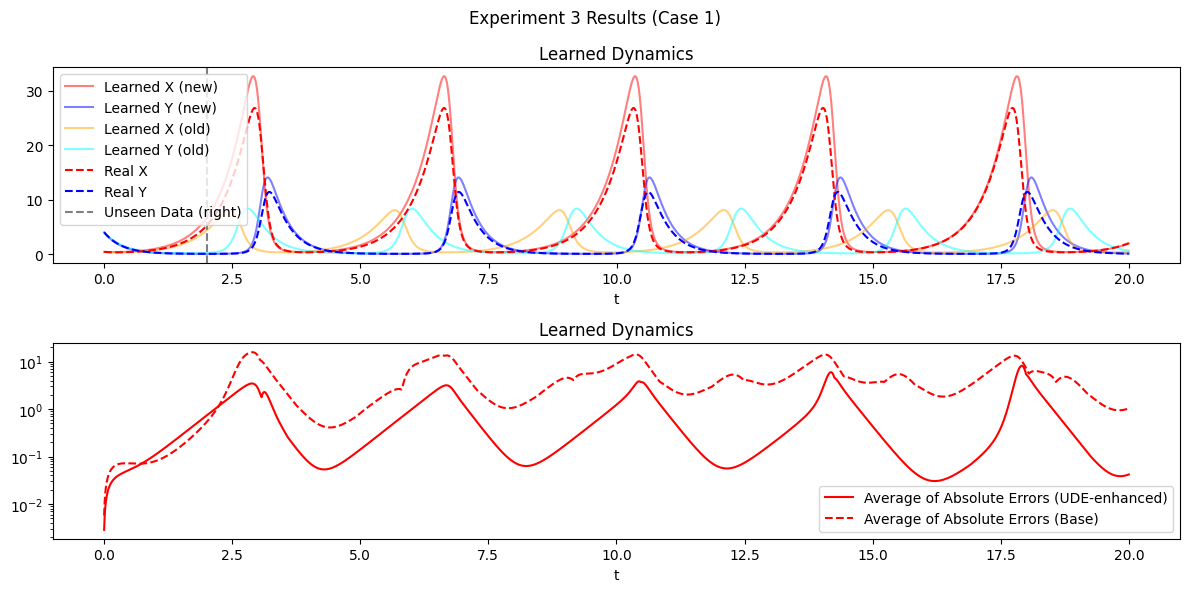

In [ ]:
#(x)' =  1.256 x + -0.815 x y
# (y)' = -1.729 y +  0.506 x y
# old parameters
alpha_old = 2.002
delta_old = 3.007
beta_old = 0.997
gamma_old = 1.256

# new parameters
alpha = 1.993
delta = 3.053
beta = 0.836
gamma = 0.426

# real parameters
alpha_real = 2
delta_real = 3
beta_real = 1
gamma_real = 0.5


def lotka_volterra(t, data, a, d, b, gamma):
    x = data[0]
    y = data[1]
    return np.array([a * x - b * x * y, 
                    -d * y + gamma * x * y])

x0 = (0.4, 4)

T_MAX = 20

sol_old = solve_ivp(lotka_volterra, t_span = [0, T_MAX], t_eval=np.arange(0, T_MAX, 0.01), args= (alpha_old, delta_old, beta_old, gamma_old), y0 = x0, rtol=1e-9, atol=1e-9)
sol = solve_ivp(lotka_volterra, t_span = [0, T_MAX], t_eval=np.arange(0, T_MAX, 0.01), args= (alpha, delta, beta, gamma), y0 = x0, rtol=1e-9, atol=1e-9)
sol_real = solve_ivp(lotka_volterra, t_span = [0, T_MAX], t_eval=np.arange(0, T_MAX, 0.01), args= (alpha_real, delta_real, beta_real, gamma_real), y0 = x0, rtol=1e-9, atol=1e-9)
data_old = sol_old.y
data = sol.y
data_real = sol_real.y



T = sol.t
X = data[0]
Y = data[1]

X_real = data_real[0]
Y_real = data_real[1]
X_old = data_old[0]
Y_old = data_old[1]

fig, axes = plt.subplots(2,1, figsize=(12, 6))

plt.sca(axes[0])

plt.plot(T, X, "-", label="Learned X (UDE)", color="red", alpha=0.5)
plt.plot(T, Y, "-", label="Learned Y (UDE)", color="blue", alpha=0.5)
plt.plot(T, X_old, "-", label="Learned X (BASE)", color="orange", alpha=0.5)
plt.plot(T, Y_old, "-", label="Learned Y (BASE)", color="cyan", alpha=0.5)
plt.plot(T, X_real, "--", label="Real X", color="red")
plt.plot(T, Y_real, "--", label="Real Y", color="blue")
plt.axvline(2, linestyle="--", color="grey", label="Unseen Data (right)")
plt.xlabel("t")
plt.title("Learned Dynamics")
plt.legend()

plt.sca(axes[1])
plt.semilogy(T[1:], 0.5*(np.abs(X[1:]-X_real[1:])+ np.abs(Y[1:]-Y_real[1:])), label="Average of Absolute Errors (UDE-enhanced)", color='red')
plt.semilogy(T[1:], 0.5*(np.abs(X_old[1:]-X_real[1:])+np.abs(Y_old[1:]-Y_real[1:])), label="Average of Absolute Errors (Base)", color='red', linestyle="--")
plt.xlabel("t")
plt.title("Learned Dynamics")
plt.legend()

plt.suptitle("Experiment 3 Results (Case 1)")
plt.tight_layout()

plt.show()




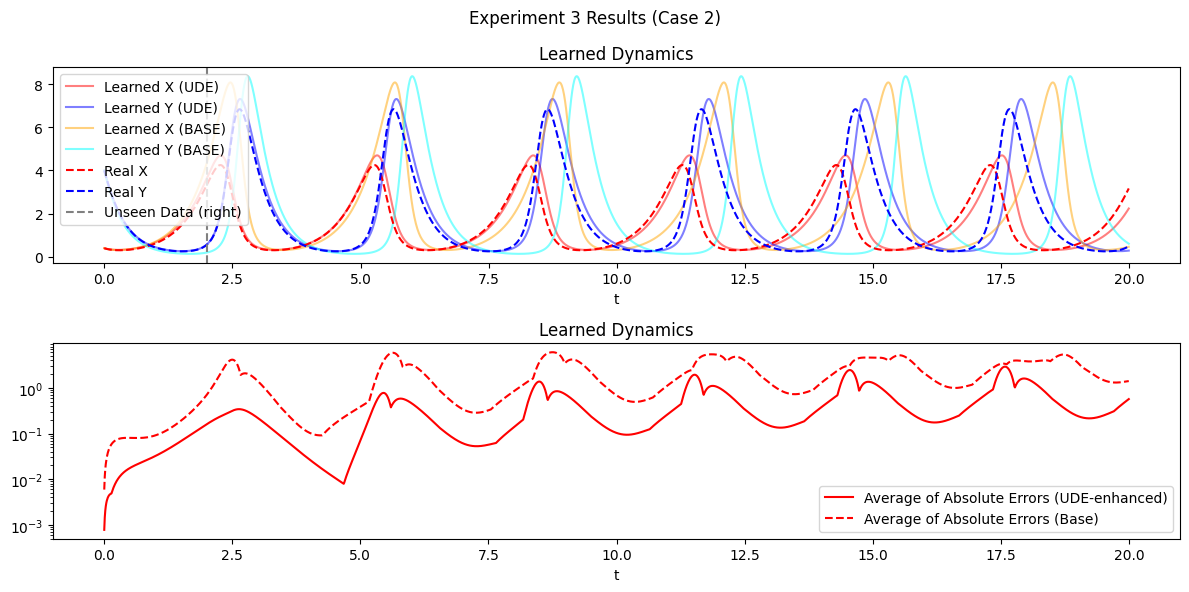

In [147]:
#(x)' =  1.256 x + -0.815 x y
# (y)' = -1.729 y +  0.506 x y
# old parameters
alpha_old = 2.002
beta_old = 0.997
delta_old = 3.007
gamma_old = 1.256

# new parameters
alpha = 1.998
beta = 0.942
delta = 2.939
gamma = 1.801

# real parameters
alpha_real = 2
delta_real = 3
beta_real = 1
gamma_real = 2


def lotka_volterra(t, data, a, d, b, gamma):
    x = data[0]
    y = data[1]
    return np.array([a * x - b * x * y, 
                    -d * y + gamma * x * y])

x0 = (0.4, 4)

T_MAX = 20

sol_old = solve_ivp(lotka_volterra, t_span = [0, T_MAX], t_eval=np.arange(0, T_MAX, 0.01), args= (alpha_old, delta_old, beta_old, gamma_old), y0 = x0, rtol=1e-9, atol=1e-9)
sol = solve_ivp(lotka_volterra, t_span = [0, T_MAX], t_eval=np.arange(0, T_MAX, 0.01), args= (alpha, delta, beta, gamma), y0 = x0, rtol=1e-9, atol=1e-9)
sol_real = solve_ivp(lotka_volterra, t_span = [0, T_MAX], t_eval=np.arange(0, T_MAX, 0.01), args= (alpha_real, delta_real, beta_real, gamma_real), y0 = x0, rtol=1e-9, atol=1e-9)
data_old = sol_old.y
data = sol.y
data_real = sol_real.y



T = sol.t
X = data[0]
Y = data[1]

X_real = data_real[0]
Y_real = data_real[1]
X_old = data_old[0]
Y_old = data_old[1]

fig, axes = plt.subplots(2,1, figsize=(12, 6))

plt.sca(axes[0])

plt.plot(T, X, "-", label="Learned X (UDE)", color="red", alpha=0.5)
plt.plot(T, Y, "-", label="Learned Y (UDE)", color="blue", alpha=0.5)
plt.plot(T, X_old, "-", label="Learned X (BASE)", color="orange", alpha=0.5)
plt.plot(T, Y_old, "-", label="Learned Y (BASE)", color="cyan", alpha=0.5)
plt.plot(T, X_real, "--", label="Real X", color="red")
plt.plot(T, Y_real, "--", label="Real Y", color="blue")
plt.axvline(2, linestyle="--", color="grey", label="Unseen Data (right)")
plt.xlabel("t")
plt.title("Learned Dynamics")
plt.legend()

plt.sca(axes[1])
plt.semilogy(T[1:], 0.5*(np.abs(X[1:]-X_real[1:])+ np.abs(Y[1:]-Y_real[1:])), label="Average of Absolute Errors (UDE-enhanced)", color='red')
plt.semilogy(T[1:], 0.5*(np.abs(X_old[1:]-X_real[1:])+np.abs(Y_old[1:]-Y_real[1:])), label="Average of Absolute Errors (Base)", color='red', linestyle="--")
plt.xlabel("t")
plt.title("Learned Dynamics")
plt.legend()

plt.suptitle("Experiment 3 Results (Case 2)")
plt.tight_layout()

plt.show()


